In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

np.random.seed(42)
sns.set_style("whitegrid")

TASK1  

In [2]:
N = 100000

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

inside = x**2 + y**2 <= 1

points_inside = np.sum(inside)

pi_estimate = 4 * points_inside / N

print("Estimated π:", pi_estimate)
print("True π:", np.pi)

Estimated π: 3.14412
True π: 3.141592653589793


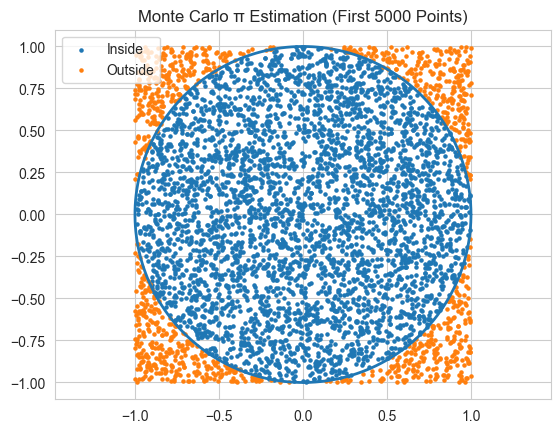

In [3]:
sample = 5000

plt.figure()

plt.scatter(x[:sample][inside[:sample]],
            y[:sample][inside[:sample]],
            s=5,
            label="Inside")

plt.scatter(x[:sample][~inside[:sample]],
            y[:sample][~inside[:sample]],
            s=5,
            label="Outside")


theta = np.linspace(0, 2*np.pi, 400)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

plt.plot(circle_x, circle_y, linewidth=2)

plt.title("Monte Carlo π Estimation (First 5000 Points)")
plt.legend()
plt.axis("equal")
plt.show()

In [4]:
step = 100
running_estimates = []

for n in range(step, N+1, step):
    estimate = 4 * np.sum(inside[:n]) / n
    running_estimates.append(estimate)

x_axis = np.arange(step, N+1, step)

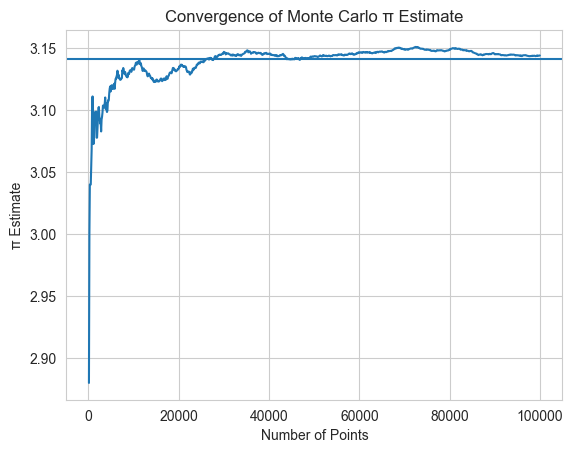

In [5]:
plt.figure()

plt.plot(x_axis, running_estimates)
plt.axhline(np.pi)

plt.title("Convergence of Monte Carlo π Estimate")
plt.xlabel("Number of Points")
plt.ylabel("π Estimate")

plt.show()

The π estimate usually stabilizes within ±0.01 around ~20,000–40,000 samples.

Monte Carlo error decreases roughly as:

error ~ 1/(squareroot(N))

So improvements become slower as N increases.

TASK2

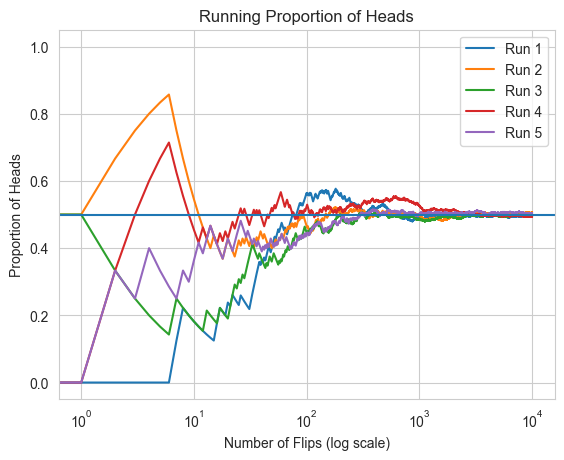

In [6]:
flips = 10000
experiments = 5

plt.figure()

for i in range(experiments):

    flips_data = np.random.binomial(1, 0.5, flips)

    cumulative_heads = np.cumsum(flips_data)

    running_proportion = cumulative_heads / np.arange(1, flips+1)

    plt.plot(running_proportion, label=f"Run {i+1}")

plt.axhline(0.5)

plt.xscale("log")

plt.title("Running Proportion of Heads")
plt.xlabel("Number of Flips (log scale)")
plt.ylabel("Proportion of Heads")

plt.legend()

plt.show()


The running proportion usually stays within ±0.01 after ~3,000–5,000 flips.
Early flips fluctuate heavily, but the Law of Large Numbers forces convergence toward 0.5.

TASK3

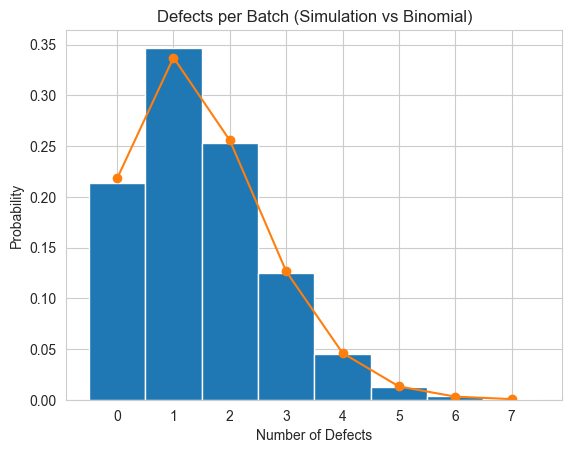

In [7]:
batches = 10000
n = 50
p = 0.03

defects = np.random.binomial(n, p, batches)

plt.figure()

bins = np.arange(defects.max()+2) - 0.5
plt.hist(defects, bins=bins, density=True)

x = np.arange(0, defects.max()+1)
pmf = binom.pmf(x, n, p)



plt.plot(x, pmf, marker="o")

plt.title("Defects per Batch (Simulation vs Binomial)")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")

plt.show()

In [8]:
p0_sim = np.mean(defects == 0)
p3plus_sim = np.mean(defects >= 3)
expected_sim = np.mean(defects)

p0_theory = binom.pmf(0, n, p)
p3plus_theory = 1 - binom.cdf(2, n, p)
expected_theory = n * p

In [9]:

print("\nSimulation Estimates")
print("P(0 defects):", p0_sim)
print("P(3+ defects):", p3plus_sim)
print("Expected defects:", expected_sim)



print("\nTheoretical Values")
print("P(0 defects):", p0_theory)
print("P(3+ defects):", p3plus_theory)
print("Expected defects:", expected_theory)


Simulation Estimates
P(0 defects): 0.2132
P(3+ defects): 0.1867
Expected defects: 1.4978

Theoretical Values
P(0 defects): 0.21806537534740766
P(3+ defects): 0.18920192463027874
Expected defects: 1.5


Empirical estimates with 10,000 batches are usually extremely close to theoretical values.
With only 1,000 batches, results would still be reasonable but noisier.